# Baseline Machine Learning Classification from Functional Connectivity

## Goal

This notebook builds an exploratory machine learning pipeline using functional connectivity features.

The goal is not to create a clinical diagnostic model, but to demonstrate how subject-level connectomes can be converted into feature vectors and used in a leakage-safe classification workflow.

## Important limitation

The current sample size is very small. Therefore, classification metrics should be interpreted only as a technical validation of the pipeline, not as scientific or clinical evidence.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.statistics import vectorize_upper_triangle
from src.modeling import evaluate_leave_one_out_classifier, metrics_to_dataframe

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONNECTIVITY_DIR = PROCESSED_DIR / "connectivity"


## Load subject-level connectivity results

In [2]:
results_path = PROCESSED_DIR / "group_connectivity_results.tsv"

results_df = pd.read_csv(results_path, sep="\t")

successful_subjects = results_df[results_df["status"] == "success"].copy()

successful_subjects


,participant_id,diagnosis,time_series_shape,matrix_shape,status
0,sub-70060,ADHD,"(152, 48)","(48, 48)",success
2,sub-60022,BIPOLAR,"(152, 48)","(48, 48)",success
3,sub-60080,BIPOLAR,"(152, 48)","(48, 48)",success
4,sub-10347,CONTROL,"(152, 48)","(48, 48)",success
5,sub-11090,CONTROL,"(152, 48)","(48, 48)",success
6,sub-50023,SCHZ,"(152, 48)","(48, 48)",success
7,sub-50066,SCHZ,"(152, 48)","(48, 48)",success


In [3]:
successful_subjects["diagnosis"].value_counts()


diagnosis
BIPOLAR    2
CONTROL    2
SCHZ       2
ADHD       1
Name: count, dtype: int64

## Load and vectorize connectivity matrices

In [4]:
X = []
y_multiclass = []
subject_ids = []

for _, row in successful_subjects.iterrows():
    subject_id = row["participant_id"]
    diagnosis = row["diagnosis"]
    
    matrix_path = CONNECTIVITY_DIR / f"{subject_id}_connectivity_matrix.npy"
    
    if not matrix_path.exists():
        print(f"Missing matrix: {matrix_path}")
        continue
    
    matrix = np.load(matrix_path)
    vector, _ = vectorize_upper_triangle(matrix)
    
    X.append(vector)
    y_multiclass.append(diagnosis)
    subject_ids.append(subject_id)

X = np.vstack(X)
y_multiclass = np.array(y_multiclass)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y_multiclass.shape}")


Feature matrix shape: (7, 1128)
Labels shape: (7,)


## Multiclass classification

This task attempts to classify diagnostic groups directly.

Because the sample size is very small, this section is included only to demonstrate the classification workflow.


In [5]:
multiclass_metrics = evaluate_leave_one_out_classifier(X, y_multiclass)

metrics_to_dataframe(multiclass_metrics)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,n_samples,n_evaluated_samples,skipped_folds
0,0.0,0.0,0.0,0.0,7,7,0


In [6]:
print(multiclass_metrics["classification_report"])


              precision    recall  f1-score   support

        ADHD       0.00      0.00      0.00       1.0
     BIPOLAR       0.00      0.00      0.00       2.0
     CONTROL       0.00      0.00      0.00       2.0
        SCHZ       0.00      0.00      0.00       2.0

    accuracy                           0.00       7.0
   macro avg       0.00      0.00      0.00       7.0
weighted avg       0.00      0.00      0.00       7.0



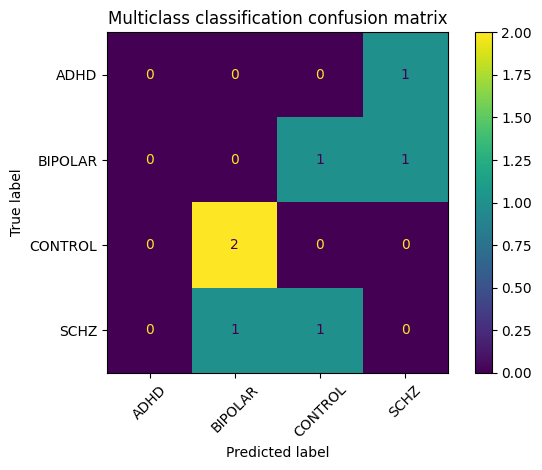

In [7]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=multiclass_metrics["confusion_matrix"],
    display_labels=multiclass_metrics["labels"],
)

disp.plot(xticks_rotation=45)
plt.title("Multiclass classification confusion matrix")
plt.tight_layout()
plt.show()


## Binary classification: psychiatric group vs healthy controls

This task collapses all psychiatric diagnoses into a single group and compares them against healthy controls.


In [8]:
y_binary = np.where(y_multiclass == "CONTROL", "CONTROL", "PSYCHIATRIC")

pd.Series(y_binary).value_counts()


PSYCHIATRIC    5
CONTROL        2
Name: count, dtype: int64

In [9]:
binary_metrics = evaluate_leave_one_out_classifier(X, y_binary)

metrics_to_dataframe(binary_metrics)


,accuracy,balanced_accuracy,macro_f1,weighted_f1,n_samples,n_evaluated_samples,skipped_folds
0,0.428571,0.3,0.3,0.428571,7,7,0


In [10]:
print(binary_metrics["classification_report"])


              precision    recall  f1-score   support

     CONTROL       0.00      0.00      0.00         2
 PSYCHIATRIC       0.60      0.60      0.60         5

    accuracy                           0.43         7
   macro avg       0.30      0.30      0.30         7
weighted avg       0.43      0.43      0.43         7



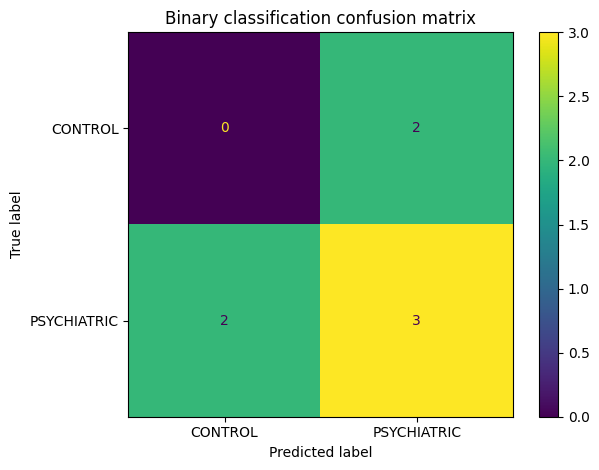

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=binary_metrics["confusion_matrix"],
    display_labels=binary_metrics["labels"],
)

disp.plot()
plt.title("Binary classification confusion matrix")
plt.tight_layout()
plt.show()


## Save ML results

In [12]:
ml_dir = PROCESSED_DIR / "ml"
ml_dir.mkdir(parents=True, exist_ok=True)

multiclass_metrics_path = ml_dir / "multiclass_metrics.tsv"
binary_metrics_path = ml_dir / "binary_metrics.tsv"
multiclass_predictions_path = ml_dir / "multiclass_predictions.tsv"
binary_predictions_path = ml_dir / "binary_predictions.tsv"

metrics_to_dataframe(multiclass_metrics).to_csv(
    multiclass_metrics_path,
    sep="\t",
    index=False,
)

metrics_to_dataframe(binary_metrics).to_csv(
    binary_metrics_path,
    sep="\t",
    index=False,
)

subject_ids_array = np.array(subject_ids)

multiclass_indices = multiclass_metrics["evaluated_indices"]
binary_indices = binary_metrics["evaluated_indices"]

multiclass_predictions_df = pd.DataFrame({
    "participant_id": subject_ids_array[multiclass_indices],
    "true_label": multiclass_metrics["y_true"],
    "predicted_label": multiclass_metrics["y_pred"],
})

binary_predictions_df = pd.DataFrame({
    "participant_id": subject_ids_array[binary_indices],
    "true_label": binary_metrics["y_true"],
    "predicted_label": binary_metrics["y_pred"],
})

multiclass_predictions_df.to_csv(
    multiclass_predictions_path,
    sep="\t",
    index=False,
)

binary_predictions_df.to_csv(
    binary_predictions_path,
    sep="\t",
    index=False,
)

print(f"Saved: {multiclass_metrics_path}")
print(f"Saved: {binary_metrics_path}")
print(f"Saved: {multiclass_predictions_path}")
print(f"Saved: {binary_predictions_path}")

Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\ml\multiclass_metrics.tsv
Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\ml\binary_metrics.tsv
Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\ml\multiclass_predictions.tsv
Saved: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\ml\binary_predictions.tsv


## Summary

This notebook implemented a baseline machine learning workflow for functional connectivity features.

Completed steps:

- loaded subject-level connectivity matrices;
- vectorized upper-triangle connectivity edges;
- built leakage-safe classification pipelines using scaling inside cross-validation;
- evaluated multiclass diagnostic classification;
- evaluated binary psychiatric-vs-control classification;
- saved metrics and prediction tables.

Important limitation:

The current sample size is too small for scientific interpretation. Some Leave-One-Out folds may be skipped when the training set contains only one class. The purpose of this notebook is to demonstrate a reproducible ML workflow that can be scaled to larger samples.
